In [394]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from typing import Literal

In [395]:
SIZE = 500
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED);

### Датасет

In [396]:
X, y = make_moons(n_samples=SIZE, noise=0.1, random_state=SEED)

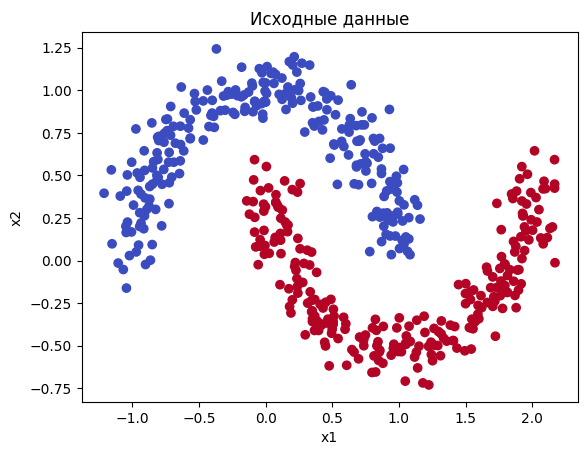

In [397]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title('Исходные данные')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### Обучение MLP

In [ ]:
class MLP(nn.Module):
    def __init__(
        self, 
        input_size: int, 
        hidden_size: int, 
        activation: Literal['relu', 'sigmoid', 'tanh'] = 'relu', 
        output_size: int = 1
    ):
        super().__init__()
        self.ln1 = nn.Linear(input_size, hidden_size)
        self.actfun = nn.ReLU() if activation == 'relu' else nn.Tanh() if activation == 'tanh' else nn.Sigmoid()
        self.ln2 = nn.Linear(hidden_size, output_size)
        self.outact = nn.Sigmoid()

    def forward(self, x) -> torch.Tensor:
        x = self.ln1(x)
        x = self.actfun(x)
        x = self.ln2(x)
        return self.outact(x)

    def train_model(self, x, y, epoches: int = 1000, lr: float = 0.5) -> list[float]:
        optimizer = torch.optim.SGD(self.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss() if self.ln2.out_features > 2 else nn.BCELoss()
        losses = []

        if len(y.shape) != 2:
            y = y.unsqueeze(1)

        for _ in range(epoches):
            optimizer.zero_grad()

            output = self(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        return losses


In [399]:
X, y = torch.FloatTensor(X), torch.FloatTensor(y)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [ ]:
mlp = MLP(2, 4, 'relu', 1)
losses = mlp.train_model(x_train, y_train, 1000, 2.7)

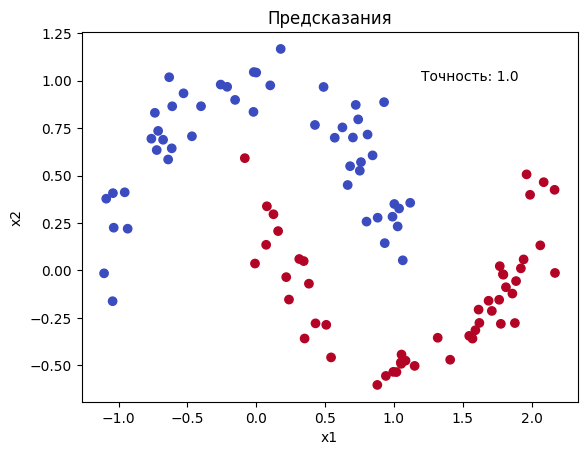

In [401]:
y_pred = mlp(torch.FloatTensor(x_test))[:, 0] > 0.5

plt.scatter(x_test[:, 0], x_test[:, 1], c=y_pred, cmap='coolwarm')
plt.title('Предсказания')
plt.xlabel('x1')
plt.ylabel('x2')
plt.text(1.2, 1., f'Точность: {(y_pred == y_test).sum().item() / len(y_test)}')
plt.show()

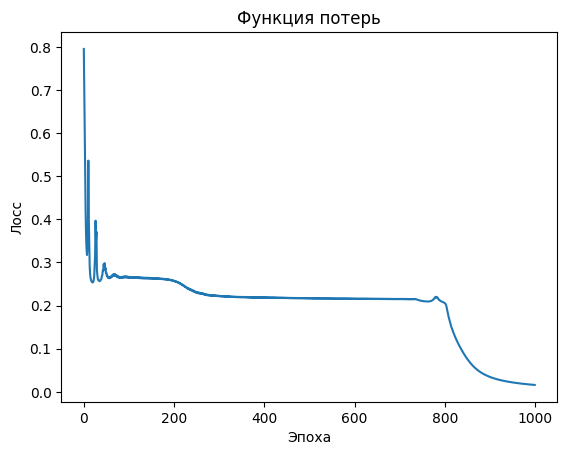

In [402]:
plt.plot(range(1000), losses)
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Лосс');